In [28]:
# load packages
library(dplyr)
library(readr)
library(ggplot2)

# read my own pumpkins file
pumpkins <- read_csv("../Pumpkins/pumpkins_datasets/pumpkins_15.csv")


# look at the data
head(pumpkins)


Rows: 15956 Columns: 15
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (10): id, place, grower_name, city, state_prov, country, gpc_site, seed_...
dbl  (5): weight_lbs, ott, est_weight, pct_chart, dataset_id

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


id,place,weight_lbs,grower_name,city,state_prov,country,gpc_site,seed_mother,pollinator_father,ott,est_weight,pct_chart,variety,dataset_id
<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
2019-P,771,723.35133,"Magarian, Marc",Midway,Utah,United States,Hee Haw Farms,2077 Brandt,Self,316.6190,749.2488,0.000000,Champion,15
2016-P,1344,361.07132,"Andres, Norbert",NA,Saxony,Germany,Saechsische Meisterschaft im Kurbiswiegen,NA,NA,242.0854,322.0853,5.017957,Champion,15
2020-P,96,1829.26272,"Friesen, Dan",NA,Quebec,Canada,Port Elgin Pumpkinfest (Sunday),2294 Noel,SIB,0.0000,0.0000,0.000000,Rouge Vif d’Etampes,15
2019-P,1169,377.41027,"Tittmann, Sven",Werder,Brandenburg,Germany,Wiegemeisterschaft Berlin/Brandenburg,NA,NA,246.7432,426.6567,0.000000,Spirit,15
2015-P,849,751.38104,"Pollock, Mark",Mill Creek,Nova Scotia,Canada,The Great Howard Dill Giant Pumpkin Classic,1253 Kline,1389 Northrup,0.0000,0.0000,0.000000,Cinderella,15
2020-P,1338,80.49146,"Kuroda, Takahito","Kuwana, Mie",Other,Japan,Nippon Ichi Dodekabocha Taikai,NA,NA,0.0000,0.0000,0.000000,Big Moose,15


In [5]:
# make a year column from id (first 4 characters)
pumpkins$year <- substr(pumpkins$id, 1, 4)

# find the heaviest pumpkin 
heaviest <- pumpkins %>%
  filter(weight_lbs == max(weight_lbs, na.rm = TRUE))

heaviest


id,place,weight_lbs,grower_name,city,state_prov,country,gpc_site,seed_mother,pollinator_father,ott,est_weight,pct_chart,variety,dataset_id,year
<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>
2016-P,1,2772.458,"Vanden Bergh, Ronny",Deurle,East Flanders,Belgium,Europameisterschaft im Kurbiswiegen,2145 McMullen,1872 Willemijns,542.3599,2002.289,21.38719,Atlantic Giant,15,2016


In [9]:
library(dplyr)

# change lbs to kg
pumpkins <- pumpkins %>%
  mutate(weight_kg = weight_lbs * 0.453592)

head(pumpkins$weight_kg)



[1] 328.10638 163.77906 829.73894 171.19028 340.82043  36.51028

In [10]:
# make weight groups
pumpkins <- pumpkins %>%
  mutate(
    weight_class = ifelse(weight_kg < 200, "light",
                   ifelse(weight_kg < 500, "medium", "heavy"))
  )
# check it
table(pumpkins$weight_class)



 heavy  light medium 
  4039   4727   7190 

Warning message:
“Removed 401 rows containing missing values or values outside the scale range (`geom_point()`).”
Saving 6.67 x 6.67 in image
Warning message:
“Removed 401 rows containing missing values or values outside the scale range (`geom_point()`).”


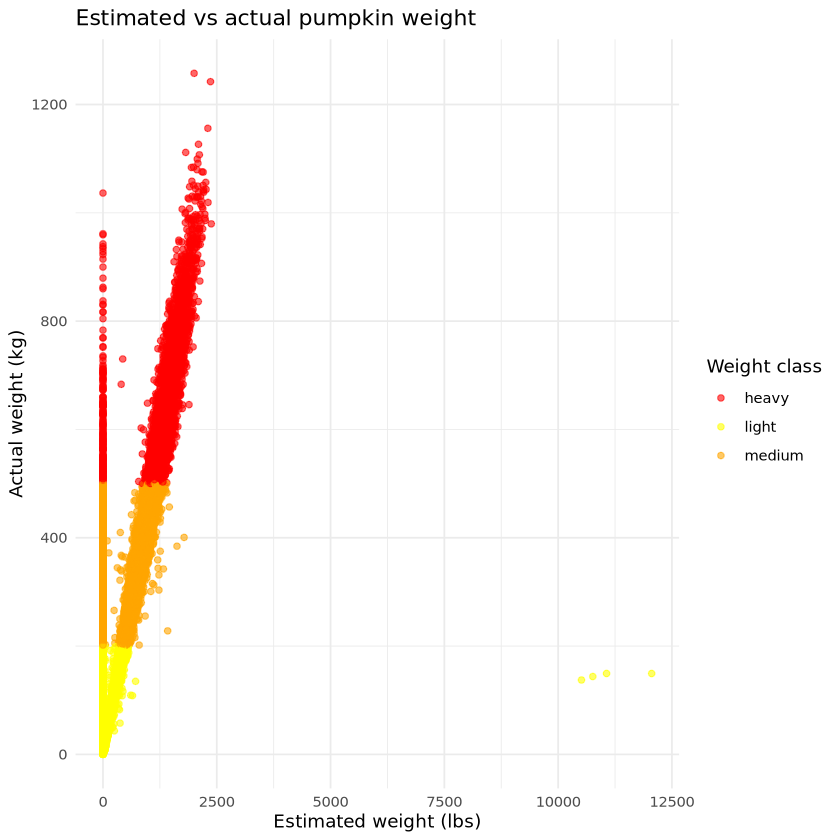

In [17]:
library(ggplot2)

# plot: estimated vs actual weight
plot1 <- ggplot(pumpkins, aes(x = est_weight, y = weight_kg, color = weight_class)) +
  geom_point(alpha = 0.6) +
scale_color_manual(values = c("light" = "yellow", 
                                "medium" = "orange",
                                "heavy" = "red")) +
  labs(
    x = "Estimated weight (lbs)",
    y = "Actual weight (kg)",
    color = "Weight class",
    title = "Estimated vs actual pumpkin weight"
  ) +
  theme_minimal()

plot1

# save plot
ggsave("Pumpkins_R/plot_estimated_vs_actual.png", plot1)






In [21]:
# check countries in the data
unique(pumpkins$country)

# keep three countries
pumpkins_three <- pumpkins %>%
  filter(country %in% c("Canada", "Japan", "Italy"))

# check it
table(pumpkins_three$country)

# save filtered data for the coursework
write_csv(pumpkins_three, "pumpkins_filtered.csv")



[1] "United States"   "Germany"         "Canada"          "Japan"          
 [5] "United Kingdom"  "Austria"         "Italy"           "France"         
 [9] "Poland"          "Belgium"         "Slovenia"        "Switzerland"    
[13] "The Netherlands" "Finland"         "Spain"           "Portugal"       
[17] "New Zealand"     "Ireland"         "Luxembourg"      "Australia"      
[21] "Unknown country"


Canada  Italy  Japan 
  2209    508    323 

In [22]:
# mean weight by country 
mean_country <- pumpkins_three %>%
  group_by(country) %>%
  summarise(mean_weight = mean(weight_kg, na.rm = TRUE))

mean_country

# mean weight by country and variety
mean_variety <- pumpkins_three %>%
  group_by(country, variety) %>%
  summarise(mean_weight = mean(weight_kg, na.rm = TRUE)) %>%
  arrange(mean_weight)

mean_variety


country,mean_weight
<chr>,<dbl>
Canada,350.8003
Italy,296.7949
Japan,138.9443


`summarise()` has grouped output by 'country'. You can override using the `.groups` argument.


country,variety,mean_weight
<chr>,<chr>,<dbl>
Japan,Wolf,101.7146
Japan,Atlantic Giant,106.0574
Japan,Dill's Atlantic,106.5600
Japan,Big Max,118.9892
Japan,Champion,122.9177
Japan,Cinderella,130.6058
Japan,Jack O'Lantern,131.7714
Japan,Prizewinner,137.0641
Japan,Howden,139.4031


Saving 6.67 x 6.67 in image


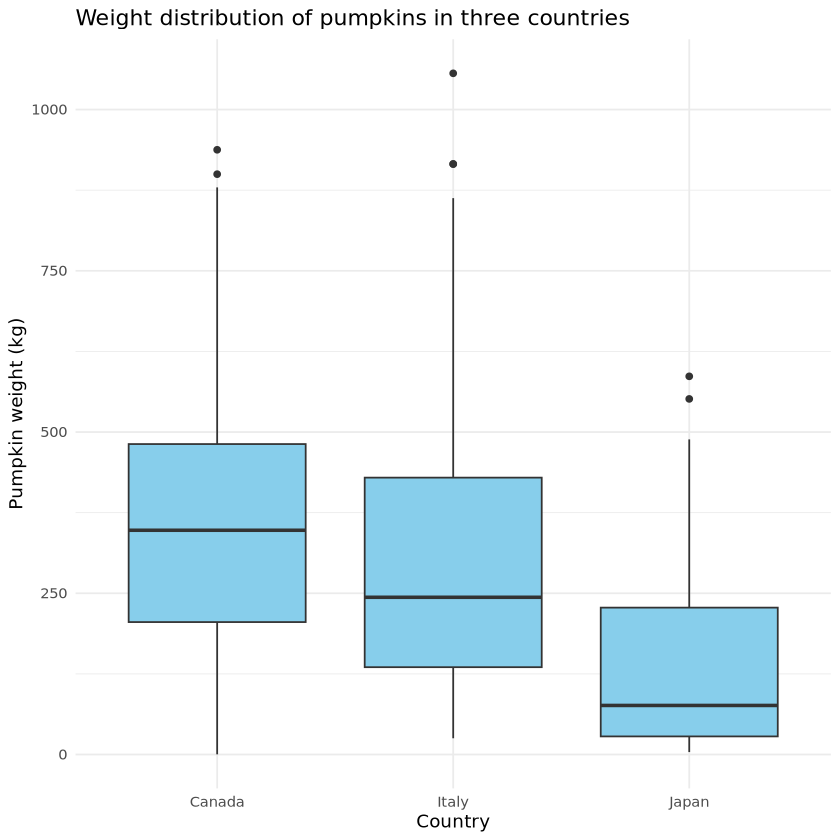

In [24]:
library(ggplot2)

# boxplot for the three countries
box1 <- ggplot(pumpkins_three, aes(x = country, y = weight_kg)) +
  geom_boxplot(fill = "skyblue") +
  labs(
    x = "Country",
    y = "Pumpkin weight (kg)",
    title = "Weight distribution of pumpkins in three countries"
  ) +
  theme_minimal()

box1

# save boxplot
ggsave("Pumpkins_R/plot_boxplot_countries.png", box1,)



Saving 6.67 x 6.67 in image


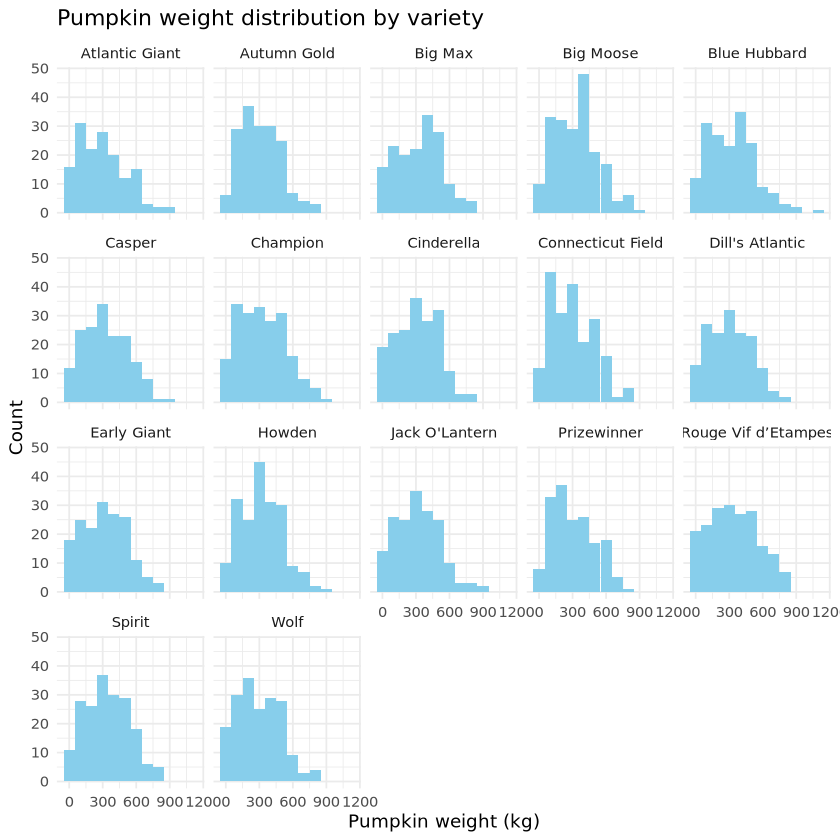

In [27]:
# facet plot by pumpkin variety
facet1 <- ggplot(pumpkins_three, aes(x = weight_kg)) +
  geom_histogram(binwidth = 100, fill = "skyblue") +
  facet_wrap(~ variety) +
  labs(
    x = "Pumpkin weight (kg)",
    y = "Count",
    title = "Pumpkin weight distribution by variety"
  ) +
  theme_minimal()

facet1

# save facet plot
ggsave("Pumpkins_R/plot_facet_variety.png", facet1,)

